# MIMIC-III NOTEEVENTS — Exploratory Data Analysis
Understanding patient and note distributions before deciding on preprocessing parameters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

CSV_PATH = "../backend/data/raw/NOTEEVENTS.csv"

# Categories used by the pipeline
PIPELINE_CATEGORIES = [
    "Discharge summary", "Physician", "Nursing",
    "Radiology", "Consult", "ECG", "Echo",
]

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## 1. Load the CSV

In [2]:
print("Streaming NOTEEVENTS.csv ...")
chunks = []
for chunk in pd.read_csv(CSV_PATH, chunksize=50_000, low_memory=False):
    chunk["CATEGORY"] = chunk["CATEGORY"].fillna("").str.strip()
    chunk = chunk[chunk["ISERROR"].isna()]
    chunk = chunk.dropna(subset=["SUBJECT_ID", "TEXT"])
    chunk["TEXT"] = chunk["TEXT"].astype(str).str.strip()
    chunk["WORD_COUNT"] = chunk["TEXT"].str.split().str.len()
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
df["CHARTDATE"] = pd.to_datetime(df["CHARTDATE"], errors="coerce")

print(f"Total rows (after removing ISERROR): {len(df):,}")
print(f"Unique patients:                     {df['SUBJECT_ID'].nunique():,}")
print(f"Unique categories:                   {df['CATEGORY'].nunique():,}")
print(f"Date range:                          {df['CHARTDATE'].min().date()} → {df['CHARTDATE'].max().date()}")

Streaming NOTEEVENTS.csv ...
Total rows (after removing ISERROR): 2,082,294
Unique patients:                     46,146
Unique categories:                   15
Date range:                          2097-12-07 → 2210-10-01


## 2. All Categories in the Dataset

In [3]:
cat_counts = df["CATEGORY"].value_counts().reset_index()
cat_counts.columns = ["Category", "Note Count"]
cat_counts["% of Total"] = (cat_counts["Note Count"] / len(df) * 100).round(2)
cat_counts["In Pipeline"] = cat_counts["Category"].isin(PIPELINE_CATEGORIES).map({True: "✓", False: ""})
print(cat_counts.to_string(index=False))

         Category  Note Count  % of Total In Pipeline
    Nursing/other      822497       39.50            
        Radiology      522279       25.08           ✓
          Nursing      223182       10.72           ✓
              ECG      209051       10.04           ✓
        Physician      141281        6.78           ✓
Discharge summary       59652        2.86           ✓
             Echo       45794        2.20           ✓
      Respiratory       31701        1.52            
        Nutrition        9400        0.45            
          General        8236        0.40            
   Rehab Services        5408        0.26            
      Social Work        2661        0.13            
  Case Management         953        0.05            
         Pharmacy         101        0.00            
          Consult          98        0.00           ✓


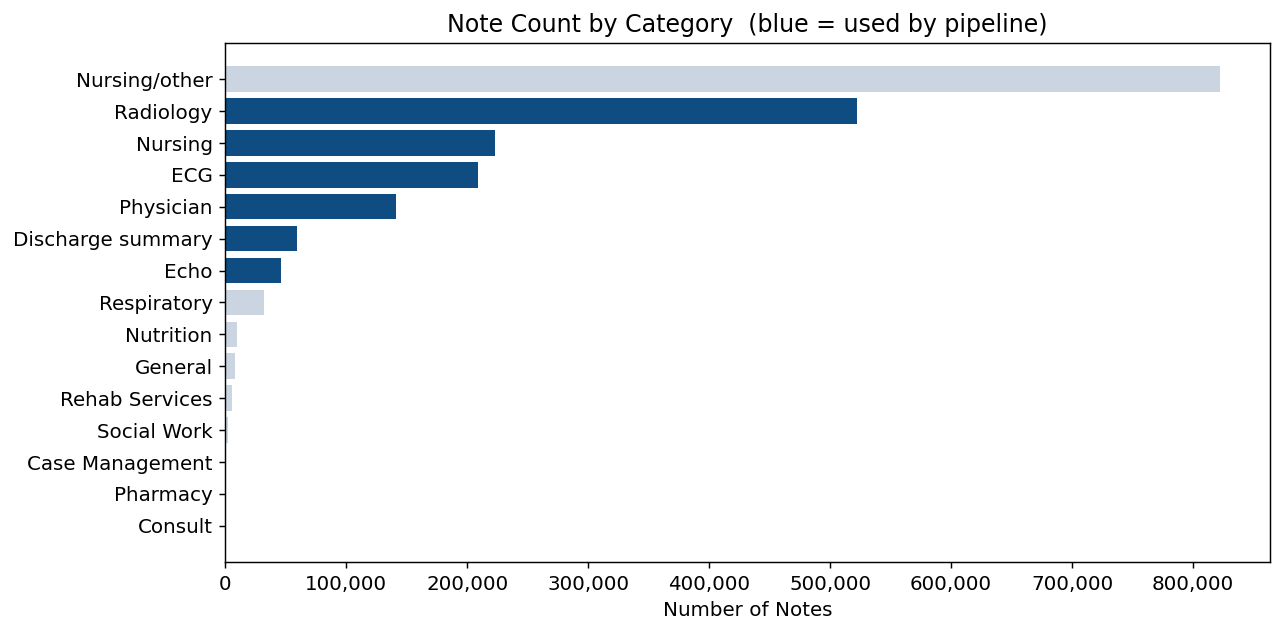

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#0f4c81" if c in PIPELINE_CATEGORIES else "#cbd5e1" for c in cat_counts["Category"]]
ax.barh(cat_counts["Category"][::-1], cat_counts["Note Count"][::-1], color=colors[::-1])
ax.set_xlabel("Number of Notes")
ax.set_title("Note Count by Category  (blue = used by pipeline)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 3. Pipeline Categories Only — Patient Coverage

In [5]:
df_pipe = df[df["CATEGORY"].isin(PIPELINE_CATEGORIES)].copy()

print(f"Notes in pipeline categories:  {len(df_pipe):,}")
print(f"Patients with any pipeline note: {df_pipe['SUBJECT_ID'].nunique():,}")

# Per-patient note count
per_patient = df_pipe.groupby("SUBJECT_ID").agg(
    total_notes=("ROW_ID", "count"),
    categories=("CATEGORY", lambda x: x.nunique()),
    first_note=("CHARTDATE", "min"),
    last_note=("CHARTDATE", "max"),
    avg_words=("WORD_COUNT", "mean"),
).reset_index()
per_patient["avg_words"] = per_patient["avg_words"].round(0).astype(int)
per_patient = per_patient.sort_values("total_notes", ascending=False).reset_index(drop=True)

print(f"\nTop 20 patients by note count:")
print(per_patient.head(20).to_string(index=False))

Notes in pipeline categories:  1,201,337
Patients with any pipeline note: 42,708

Top 20 patients by note count:
 SUBJECT_ID  total_notes  categories first_note  last_note  avg_words
      55672         1202           6 2167-09-19 2170-05-08        481
        109         1157           6 2137-11-04 2142-08-30        475
      77614         1148           6 2153-09-14 2153-12-18        524
      78076         1093           6 2113-07-01 2115-06-10        438
      30202         1060           6 2125-05-22 2125-11-19        516
      99383         1049           6 2131-05-17 2133-02-12        579
      27427          957           6 2150-03-15 2151-02-18        543
      23680          949           6 2170-06-05 2179-06-21        425
      67906          905           6 2178-06-29 2178-10-12        495
      29035          892           6 2152-07-21 2156-11-06        343
      31260          857           6 2107-08-05 2111-07-01        460
      80658          855           6 2111-03-31

## 4. Note Count Distribution Across All Patients

In [6]:
counts = per_patient["total_notes"]

print("Note count statistics (per patient, pipeline categories only):")
print(f"  Min:    {counts.min()}")
print(f"  Median: {counts.median():.0f}")
print(f"  Mean:   {counts.mean():.1f}")
print(f"  p75:    {counts.quantile(0.75):.0f}")
print(f"  p90:    {counts.quantile(0.90):.0f}")
print(f"  p95:    {counts.quantile(0.95):.0f}")
print(f"  p99:    {counts.quantile(0.99):.0f}")
print(f"  Max:    {counts.max()}")

print("\nPatients by note count bucket:")
buckets = [0, 10, 50, 100, 200, 500, 1000, 99999]
labels  = ["1–10", "11–50", "51–100", "101–200", "201–500", "501–1000", "1000+"]
per_patient["bucket"] = pd.cut(per_patient["total_notes"], bins=buckets, labels=labels)
print(per_patient["bucket"].value_counts().sort_index().to_string())

Note count statistics (per patient, pipeline categories only):
  Min:    1
  Median: 14
  Mean:   28.1
  p75:    30
  p90:    60
  p95:    96
  p99:    233
  Max:    1202

Patients by note count bucket:
bucket
1–10        16434
11–50       20821
51–100       3451
101–200      1404
201–500       532
501–1000       60
1000+           6


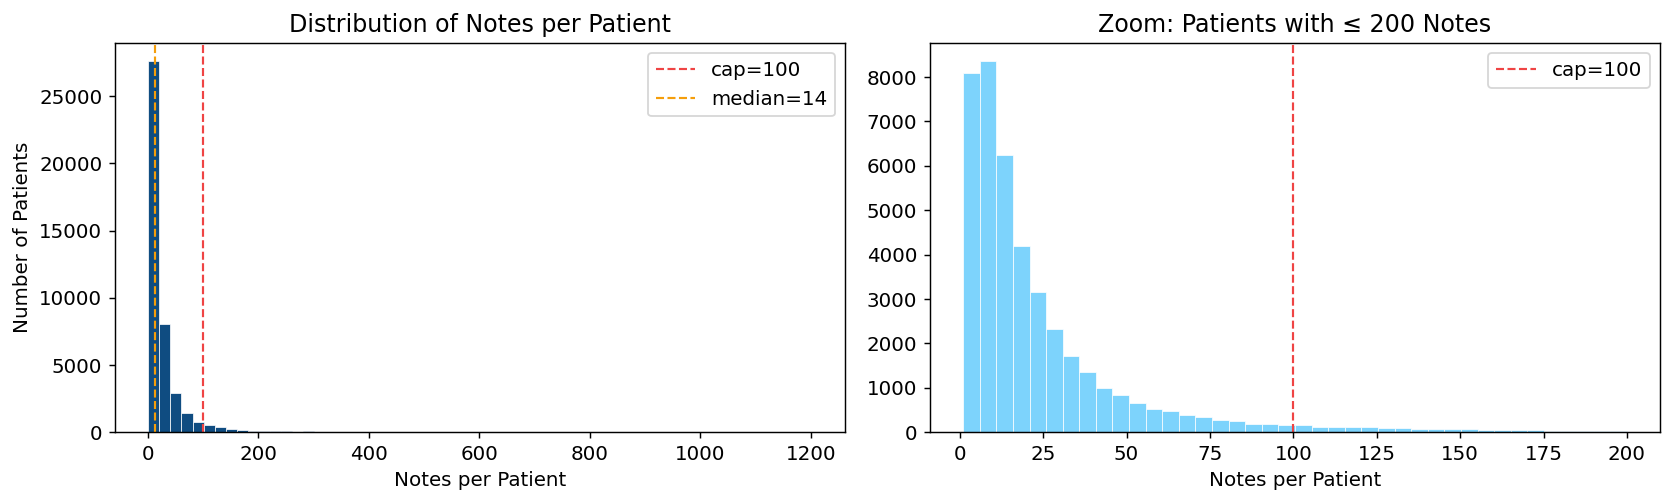

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram — all patients
axes[0].hist(counts, bins=60, color="#0f4c81", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Notes per Patient")
axes[0].set_ylabel("Number of Patients")
axes[0].set_title("Distribution of Notes per Patient")
axes[0].axvline(100,  color="#ef4444", linestyle="--", linewidth=1.2, label="cap=100")
axes[0].axvline(counts.median(), color="#f59e0b", linestyle="--", linewidth=1.2, label=f"median={counts.median():.0f}")
axes[0].legend()

# Zoom in: patients with ≤ 200 notes (majority)
axes[1].hist(counts[counts <= 200], bins=40, color="#7dd3fc", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Notes per Patient")
axes[1].set_title("Zoom: Patients with ≤ 200 Notes")
axes[1].axvline(100, color="#ef4444", linestyle="--", linewidth=1.2, label="cap=100")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. How Many Patients Would Be Cut Short by the 100-Note Cap?

In [8]:
cap = 100
under = (counts <= cap).sum()
over  = (counts >  cap).sum()
total = len(counts)

print(f"Patients with ≤ {cap} notes (cap has NO effect):  {under:,}  ({under/total*100:.1f}%)")
print(f"Patients with >  {cap} notes (cap TRUNCATES them): {over:,}  ({over/total*100:.1f}%)")
print()

# Show how much data is lost for truncated patients
truncated = per_patient[per_patient["total_notes"] > cap].copy()
truncated["notes_lost"] = truncated["total_notes"] - cap
truncated["pct_lost"]   = (truncated["notes_lost"] / truncated["total_notes"] * 100).round(1)
print(f"For patients truncated by the cap:")
print(f"  Avg notes they actually have: {truncated['total_notes'].mean():.0f}")
print(f"  Avg notes lost per patient:   {truncated['notes_lost'].mean():.0f}")
print(f"  Avg % of record lost:         {truncated['pct_lost'].mean():.1f}%")
print()
print("Worst affected patients (most notes lost):")
print(truncated.nlargest(10, "notes_lost")[["SUBJECT_ID","total_notes","notes_lost","pct_lost"]].to_string(index=False))

Patients with ≤ 100 notes (cap has NO effect):  40,706  (95.3%)
Patients with >  100 notes (cap TRUNCATES them): 2,002  (4.7%)

For patients truncated by the cap:
  Avg notes they actually have: 195
  Avg notes lost per patient:   95
  Avg % of record lost:         36.2%

Worst affected patients (most notes lost):
 SUBJECT_ID  total_notes  notes_lost  pct_lost
      55672         1202        1102      91.7
        109         1157        1057      91.4
      77614         1148        1048      91.3
      78076         1093         993      90.9
      30202         1060         960      90.6
      99383         1049         949      90.5
      27427          957         857      89.6
      23680          949         849      89.5
      67906          905         805      89.0
      29035          892         792      88.8


## 6. Category Breakdown per Patient (pipeline categories)

In [9]:
cat_pivot = (
    df_pipe.groupby(["SUBJECT_ID", "CATEGORY"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
cat_pivot["total"] = cat_pivot[list(PIPELINE_CATEGORIES)].sum(axis=1)
cat_pivot = cat_pivot.sort_values("total", ascending=False)

# Show top 30 patients
print("Category breakdown for top 30 patients by note count:")
print(cat_pivot.head(30).to_string(index=False))

Category breakdown for top 30 patients by note count:
 SUBJECT_ID  Consult  Discharge summary  ECG  Echo  Nursing  Physician  Radiology  total
      55672        0                  5   34     4      527        463        169   1202
        109        0                 34  118    13      410        362        220   1157
      77614        0                  2   11     3      716        319         97   1148
      78076        0                  5   17     4      625        288        154   1093
      30202        0                  2   18     3      386        461        190   1060
      99383        0                  4   17     2      395        481        150   1049
      27427        0                  5   16     2      460        360        114    957
      23680        0                 10   87    14      364        239        235    949
      67906        0                  4    9     4      470        310        108    905
      29035        0                 14   79    21      

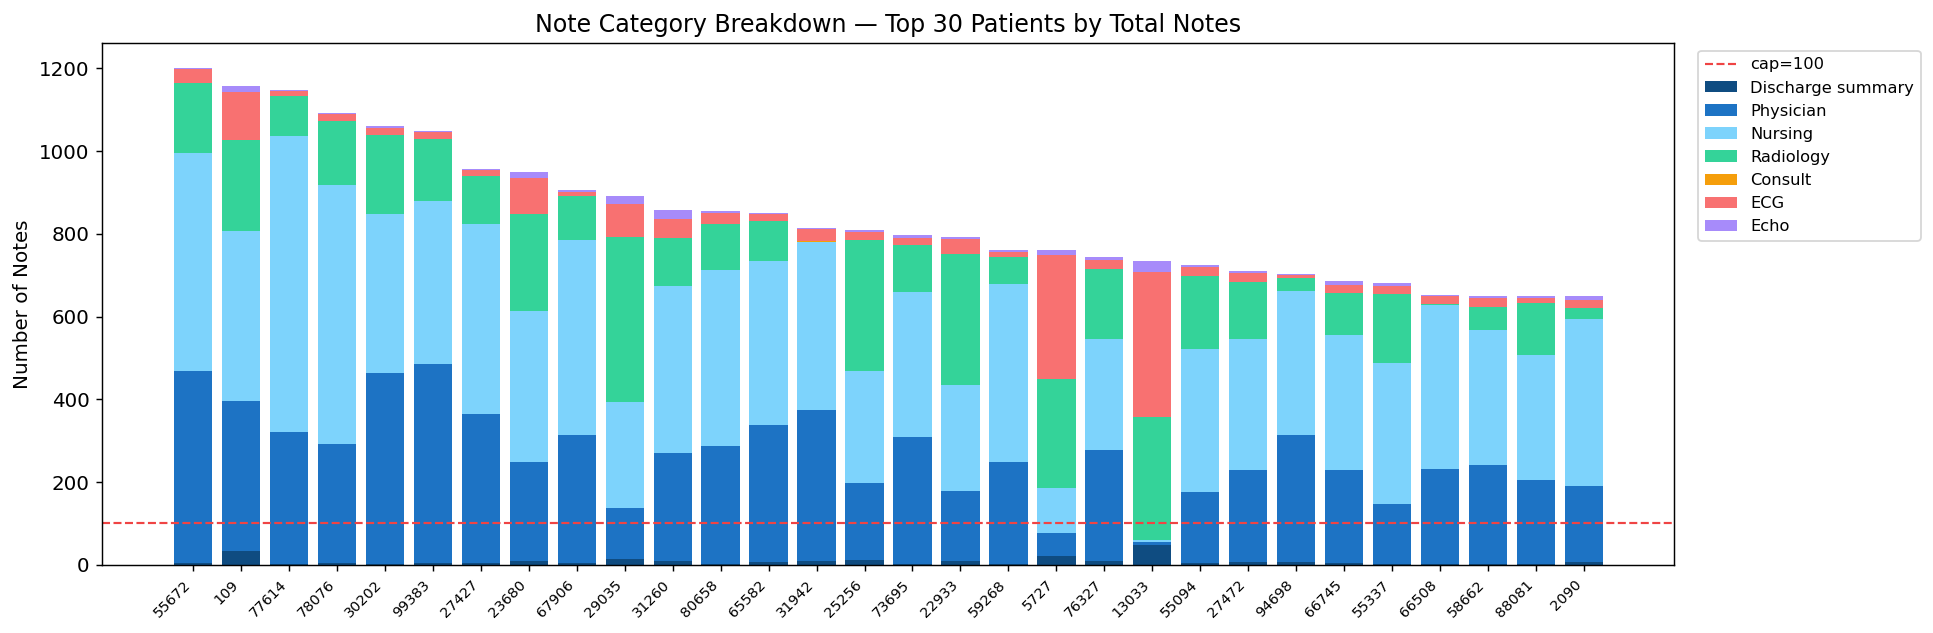

In [10]:
# Stacked bar — top 30 patients
top30 = cat_pivot.head(30).set_index("SUBJECT_ID")
plot_cols = [c for c in PIPELINE_CATEGORIES if c in top30.columns]

colors_map = {
    "Discharge summary": "#0f4c81",
    "Physician":         "#1d73c4",
    "Nursing":           "#7dd3fc",
    "Radiology":         "#34d399",
    "Consult":           "#f59e0b",
    "ECG":               "#f87171",
    "Echo":              "#a78bfa",
}

fig, ax = plt.subplots(figsize=(15, 5))
bottom = np.zeros(len(top30))
for col in plot_cols:
    vals = top30[col].values
    ax.bar(range(len(top30)), vals, bottom=bottom,
           label=col, color=colors_map.get(col, "#94a3b8"))
    bottom += vals

ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of Notes")
ax.set_title("Note Category Breakdown — Top 30 Patients by Total Notes")
ax.axhline(100, color="#ef4444", linestyle="--", linewidth=1.2, label="cap=100")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Auto-Selection Preview — Which Patients Would the Pipeline Pick?

In [11]:
MAX_PATIENTS = 100  # match your .env setting

has_discharge       = set(df_pipe[df_pipe["CATEGORY"] == "Discharge summary"]["SUBJECT_ID"].unique())
category_diversity  = df_pipe.groupby("SUBJECT_ID")["CATEGORY"].nunique()
note_counts_full    = df_pipe.groupby("SUBJECT_ID").size()

qualified = [
    pid for pid in df_pipe["SUBJECT_ID"].unique()
    if pid in has_discharge
    and category_diversity.get(pid, 0) >= 2
    and note_counts_full.get(pid, 0) >= 20
]

ranked   = note_counts_full[qualified].sort_values(ascending=False)
selected = ranked.head(MAX_PATIENTS)

print(f"Total patients with any pipeline note: {df_pipe['SUBJECT_ID'].nunique():,}")
print(f"Qualified (discharge + ≥2 cats + ≥20 notes): {len(qualified):,}")
print(f"Selected (top {MAX_PATIENTS} by note count):  {len(selected)}")
print()
print("Selected patients and their note counts:")
sel_df = pd.DataFrame({"SUBJECT_ID": selected.index, "total_notes": selected.values})
sel_df["truncated_to"] = sel_df["total_notes"].clip(upper=100)
sel_df["notes_lost"]   = (sel_df["total_notes"] - 100).clip(lower=0)
sel_df["pct_covered"]  = (sel_df["truncated_to"] / sel_df["total_notes"] * 100).round(1)
print(sel_df.to_string(index=False))

Total patients with any pipeline note: 42,708
Qualified (discharge + ≥2 cats + ≥20 notes): 16,425
Selected (top 100 by note count):  100

Selected patients and their note counts:
 SUBJECT_ID  total_notes  truncated_to  notes_lost  pct_covered
      55672         1202           100        1102          8.3
        109         1157           100        1057          8.6
      77614         1148           100        1048          8.7
      78076         1093           100         993          9.1
      30202         1060           100         960          9.4
      99383         1049           100         949          9.5
      27427          957           100         857         10.4
      23680          949           100         849         10.5
      67906          905           100         805         11.0
      29035          892           100         792         11.2
      31260          857           100         757         11.7
      80658          855           100         755   

## 8. Word Count Distribution (note length)

Word count per note (pipeline categories):
  Min:    0
  Median: 173
  Mean:   329
  p90:    825
  Max:    7980


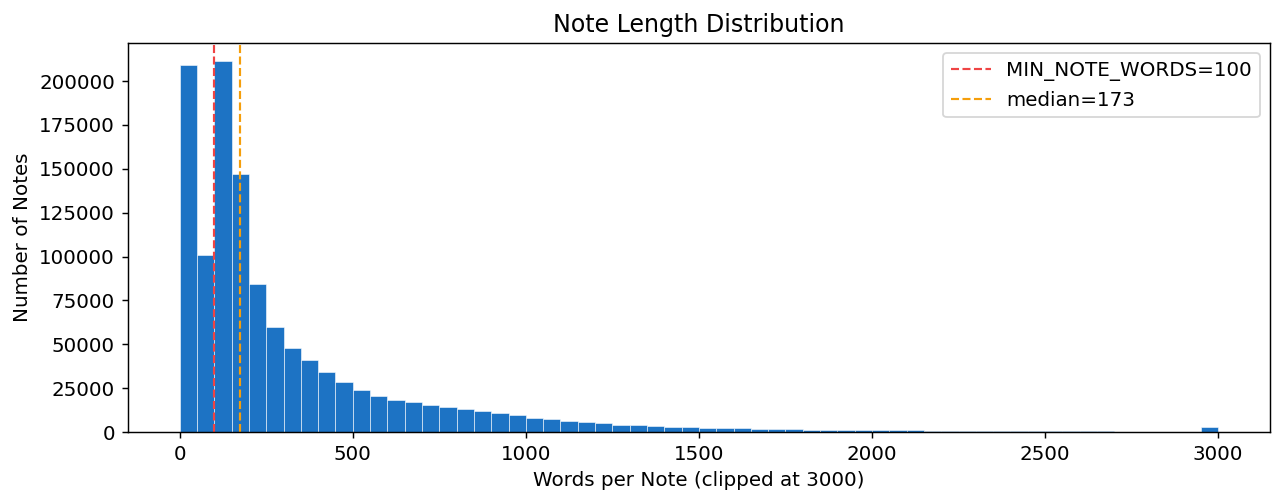

In [12]:
wc = df_pipe["WORD_COUNT"]
print("Word count per note (pipeline categories):")
print(f"  Min:    {wc.min()}")
print(f"  Median: {wc.median():.0f}")
print(f"  Mean:   {wc.mean():.0f}")
print(f"  p90:    {wc.quantile(0.90):.0f}")
print(f"  Max:    {wc.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wc.clip(upper=3000), bins=60, color="#1d73c4", edgecolor="white", linewidth=0.3)
ax.axvline(100, color="#ef4444",  linestyle="--", linewidth=1.2, label="MIN_NOTE_WORDS=100")
ax.axvline(wc.median(), color="#f59e0b", linestyle="--", linewidth=1.2, label=f"median={wc.median():.0f}")
ax.set_xlabel("Words per Note (clipped at 3000)")
ax.set_ylabel("Number of Notes")
ax.set_title("Note Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Word Count by Category

In [13]:
wc_by_cat = (
    df_pipe.groupby("CATEGORY")["WORD_COUNT"]
    .agg(["count", "median", "mean", "max"])
    .rename(columns={"count": "notes", "median": "median_words", "mean": "mean_words", "max": "max_words"})
    .round(0)
    .sort_values("median_words", ascending=False)
)
print(wc_by_cat.to_string())

                    notes  median_words  mean_words  max_words
CATEGORY                                                      
Discharge summary   59652        1328.0      1435.0       7980
Physician          141281         813.0       857.0       3443
Consult                98         678.0       760.0       2545
Echo                45794         328.0       325.0        909
Nursing            223182         235.0       263.0       3458
Radiology          522279         155.0       208.0       2828
ECG                209051          26.0        29.0        210


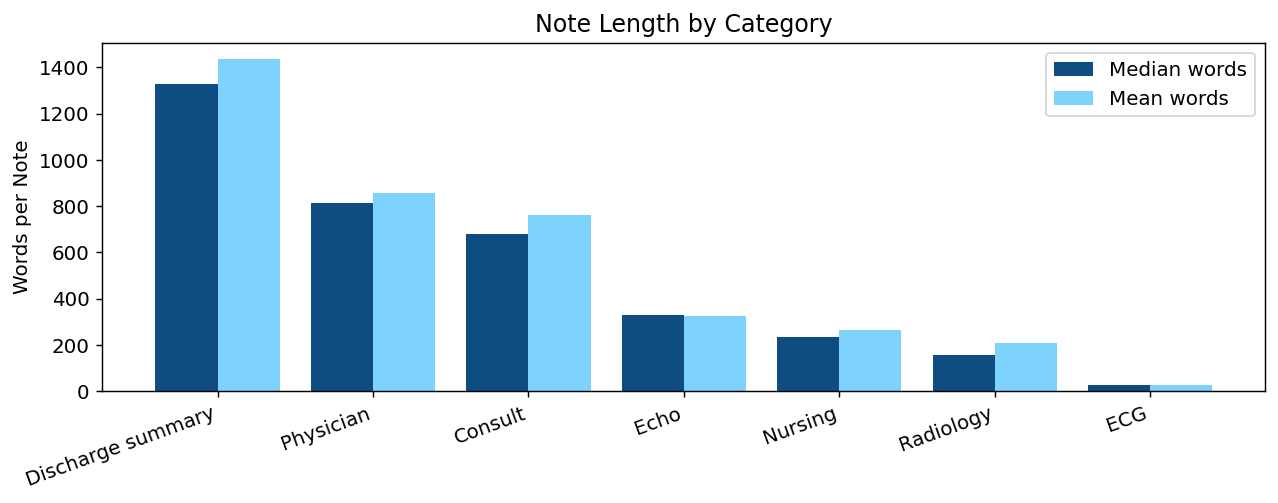

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
cats_sorted = wc_by_cat.index.tolist()
medians = wc_by_cat["median_words"].values
means   = wc_by_cat["mean_words"].values
x = np.arange(len(cats_sorted))
ax.bar(x - 0.2, medians, 0.4, label="Median words", color="#0f4c81")
ax.bar(x + 0.2, means,   0.4, label="Mean words",   color="#7dd3fc")
ax.set_xticks(x)
ax.set_xticklabels(cats_sorted, rotation=20, ha="right")
ax.set_ylabel("Words per Note")
ax.set_title("Note Length by Category")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary — Key Numbers for Pipeline Configuration

In [15]:
print("=" * 55)
print("MIMIC-III NOTEEVENTS — Pipeline Configuration Summary")
print("=" * 55)
print(f"Total notes (non-error):              {len(df):>10,}")
print(f"Notes in pipeline categories:         {len(df_pipe):>10,}")
print(f"Unique patients (pipeline):           {df_pipe['SUBJECT_ID'].nunique():>10,}")
print(f"Qualified for auto-selection:         {len(qualified):>10,}")
print()
print(f"Median notes per patient:             {note_counts_full.median():>10.0f}")
print(f"p90 notes per patient:                {note_counts_full.quantile(0.9):>10.0f}")
print(f"Max notes per patient:                {note_counts_full.max():>10,}")
print()
print(f"Patients unaffected by cap=100:       {under:>10,}  ({under/total*100:.1f}%)")
print(f"Patients truncated by cap=100:        {over:>10,}  ({over/total*100:.1f}%)")
print()
print(f"Median note length (words):           {wc.median():>10.0f}")
print(f"Discharge summary median (words):     ", end="")
print(f"{df_pipe[df_pipe['CATEGORY']=='Discharge summary']['WORD_COUNT'].median():>10.0f}")
print("=" * 55)

MIMIC-III NOTEEVENTS — Pipeline Configuration Summary
Total notes (non-error):               2,082,294
Notes in pipeline categories:          1,201,337
Unique patients (pipeline):               42,708
Qualified for auto-selection:             16,425

Median notes per patient:                     14
p90 notes per patient:                        60
Max notes per patient:                     1,202

Patients unaffected by cap=100:           40,706  (95.3%)
Patients truncated by cap=100:             2,002  (4.7%)

Median note length (words):                  173
Discharge summary median (words):           1328
